In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys
from itertools import combinations

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import torch

sys.path.append('../../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RUNS         = 5
NUM_EPOCHS     = 800
VALIDATE_EVERY = 50
PATIENCE       = 20
HOLDOUT_FRAC   = 0.20       # fraction of combo perts to hold out
HOLDOUT_SEED   = 42         # fixed seed for reproducible hold-out split
SYN_Q_THRESH   = 0.05       # FDR threshold for significant synergies
RESULTS_DIR    = 'results/reproducibility_norman'

SHERLOCK_KWARGS = dict(
    shuffle=True,
    num_workers=0,
    
    l0_lambda=24.1626289824632,
    ce_lambda=21.84665661176,
    rank=20,
    latent_dim=52,
    n_epochs_kl_warmup=185,
    
    tau_end=0.18948448049611838,
    n_epochs_l0_warmup=129,
    gate_init_p=0.5660228740609402
)

os.makedirs(f'{RESULTS_DIR}/figures', exist_ok=True)
print(f'Device: {DEVICE}  Results: {RESULTS_DIR}')

Device: cuda  Results: results/reproducibility_norman


## Load Norman 2019 data

Norman et al. 2019 (CRISPRa screen) — 105 single and 131 double perturbations in K562 cells.

In [4]:
data = sc.read_h5ad('../Norman_2019.h5ad')
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f'Cells: {data.n_obs}   Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}')

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering

Keep top 2000 HVGs (seurat_v3) union with all perturbation target genes.

In [5]:
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)
pert_mask = data.var_names.isin(pert_genes)
keep_mask = data.var['highly_variable'] | pert_mask
data = data[:, keep_mask].copy()

n_hvg       = data.var['highly_variable'].sum()
n_pert_only = (pert_mask[keep_mask] & ~data.var['highly_variable']).sum()
print(f'Kept {data.n_vars} genes  ({n_hvg} HVG + {n_pert_only} pert-only not in HVG)')

Kept 2040 genes  (2000 HVG + 40 pert-only not in HVG)


## Treatment effects

Ground-truth per-perturbation mean effects (log2-CPM vs NTC). Computed on the **full** dataset including held-out combos — used as the ATE reference throughout.

In [6]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f'treat_effect: {te.n_obs} perturbations × {te.n_vars} genes')
print(f'  single: {sum("+" not in p and p != NTC for p in te.obs_names)}   combo: {sum("+" in p for p in te.obs_names)}')

100%|████████████████████████████████████████████████████████████████████████| 236/236 [00:05<00:00, 44.39it/s]

treat_effect: 236 perturbations × 2040 genes
  single: 105   combo: 131


## Hold-out split (20% of combo perturbations)

A fixed random 20% of combo perts are held out from training across all runs.  
The model sees only single perts + the remaining 80% of combos during training.  
ATE on held-out combos tests generalisation of combinatorial predictions.

In [7]:
rng        = np.random.default_rng(HOLDOUT_SEED)
combo_arr  = np.array(sorted(combo_perts))
n_holdout  = max(1, int(np.round(len(combo_arr) * HOLDOUT_FRAC)))
holdout_idx    = rng.choice(len(combo_arr), size=n_holdout, replace=False)
holdout_combos = set(combo_arr[holdout_idx])
train_combos   = set(combo_arr) - holdout_combos

print(f'Total combo perts : {len(combo_perts)}')
print(f'Training combos   : {len(train_combos)}')
print(f'Hold-out combos   : {len(holdout_combos)}  ({len(holdout_combos)/len(combo_perts):.1%})')

# Training subset: NTC + all singles + 80% combos
train_mask = ~data.obs[p_key].isin(holdout_combos)
train_data = data[train_mask].copy()
print(f'Training cells    : {train_data.n_obs} / {data.n_obs}')

print(f'\nHeld-out combos:')
for c in sorted(holdout_combos):
    print(f'  {c}')

Total combo perts : 131
Training combos   : 105
Hold-out combos   : 26  (19.8%)
Training cells    : 103000 / 111255

Held-out combos:
  C3orf72+FOXL2
  CBFA2T3+FEV
  CBL+PTPN9
  CEBPA+CEBPB
  CEBPA+CEBPE
  CNN1+UBASH3B
  DUSP9+SNAI1
  ETS2+IGDCC3
  ETS2+IKZF3
  ETS2+MAP7D1
  FOSB+OSR2
  FOXA3+FOXF1
  FOXF1+HOXB9
  FOXL2+MEIS1
  FOXL2+ZNF318
  IGDCC3+PRTG
  IKZF3+MAPK1
  MAP2K3+MAP2K6
  MAPK1+PRTG
  PRTG+TGFBR2
  PTPN12+SAMD1
  PTPN12+UBASH3B
  RHOXF2+ZBTB25
  S1PR2+SGK1
  SNAI1+UBASH3B
  TBX2+TBX3


## Reproducibility loop

Train `N_RUNS` independent models (different random seeds) on the training subset.  
After each run:
- Compute ATE Pearson r on **held-out** combo perturbations (generalisation metric)
- Extract significant synergies (q < `SYN_Q_THRESH`) from the training combos


Run 1/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/800 [00:00<?, ?it/s…

⏹ Early stopping at epoch 539 (best ELBO=1387.7102)


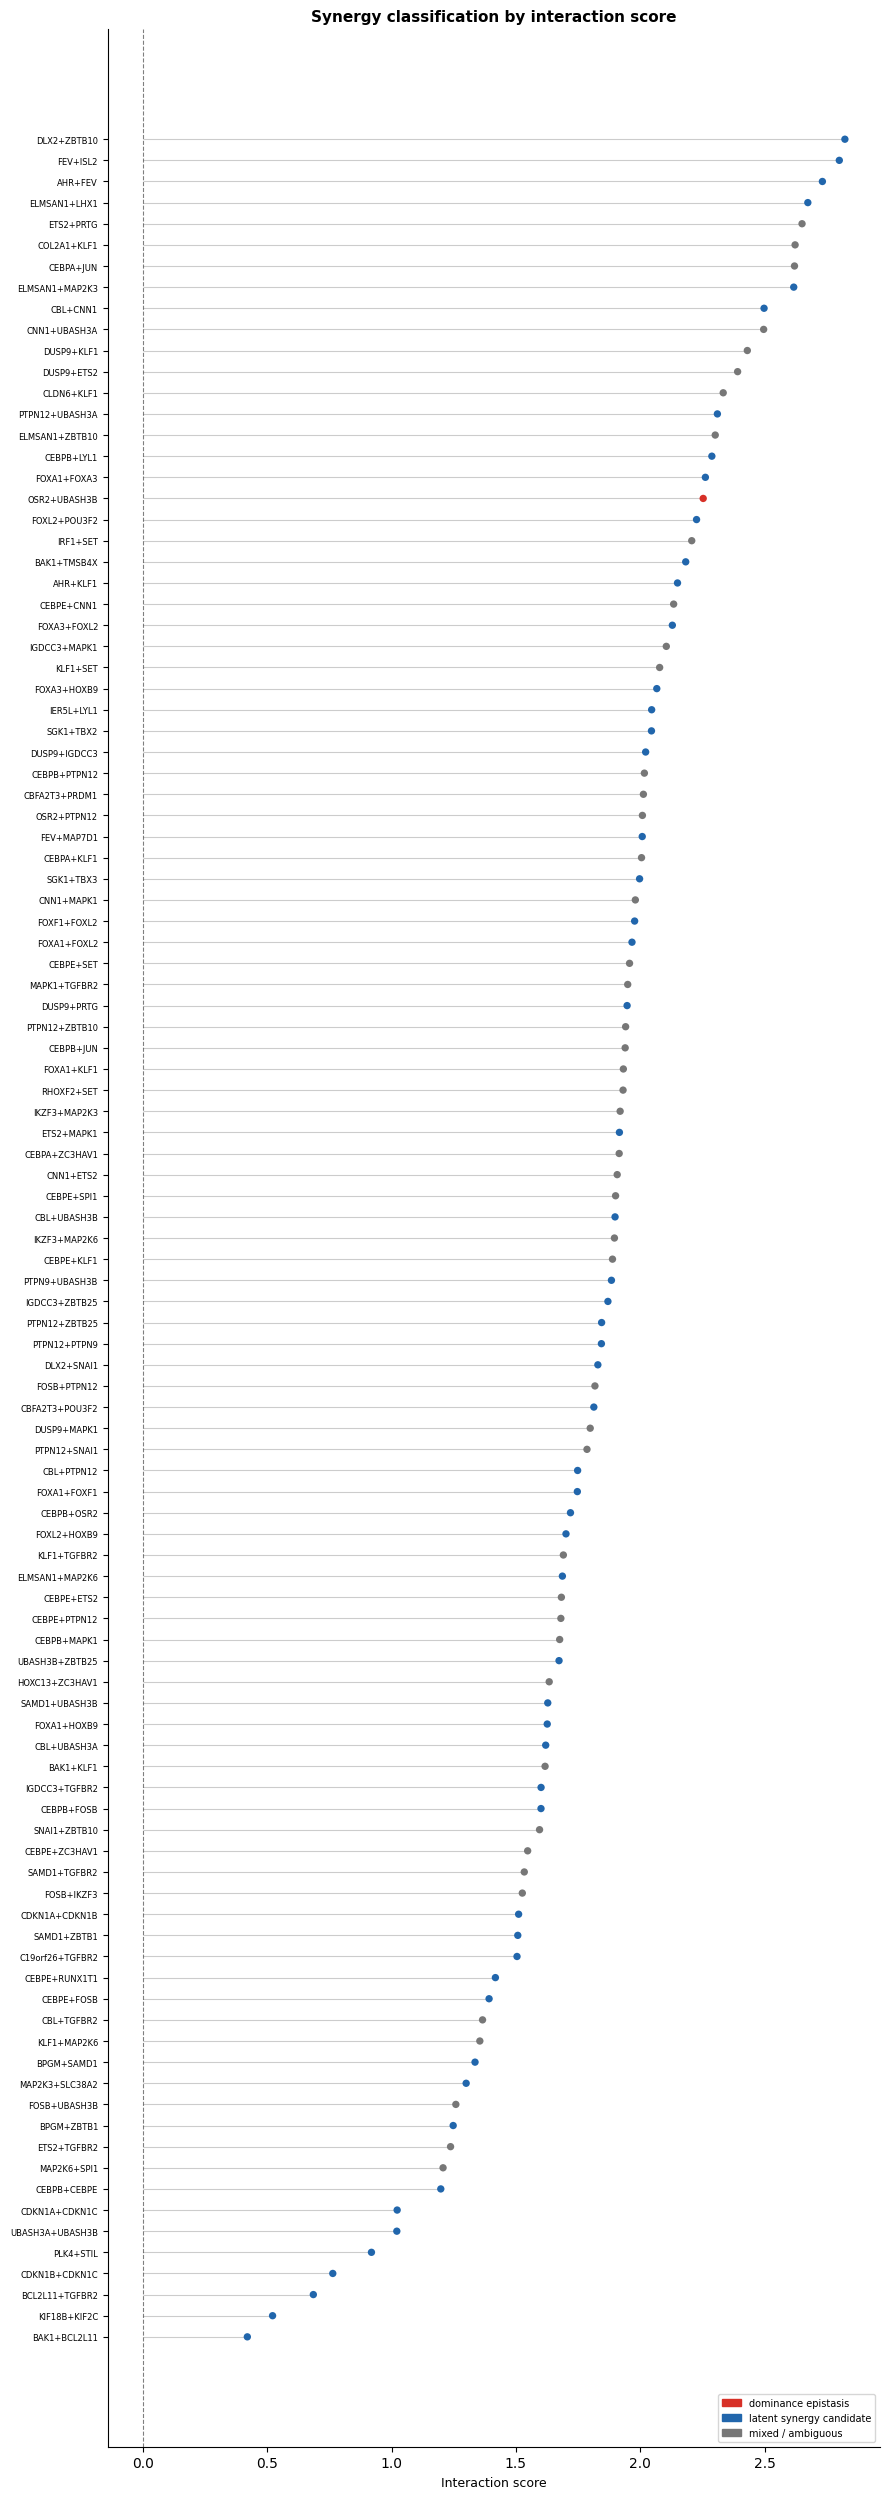

  ATE (all perts)    : 0.6917
  ATE (single perts) : 0.5565
  ATE (train combos) : 0.7432
  ATE (held-out)     : 0.7214  [n=26]
  Synergy Candidates : 57 / 105 classified

Run 2/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/800 [00:00<?, ?it/s…

⏹ Early stopping at epoch 559 (best ELBO=1386.1760)


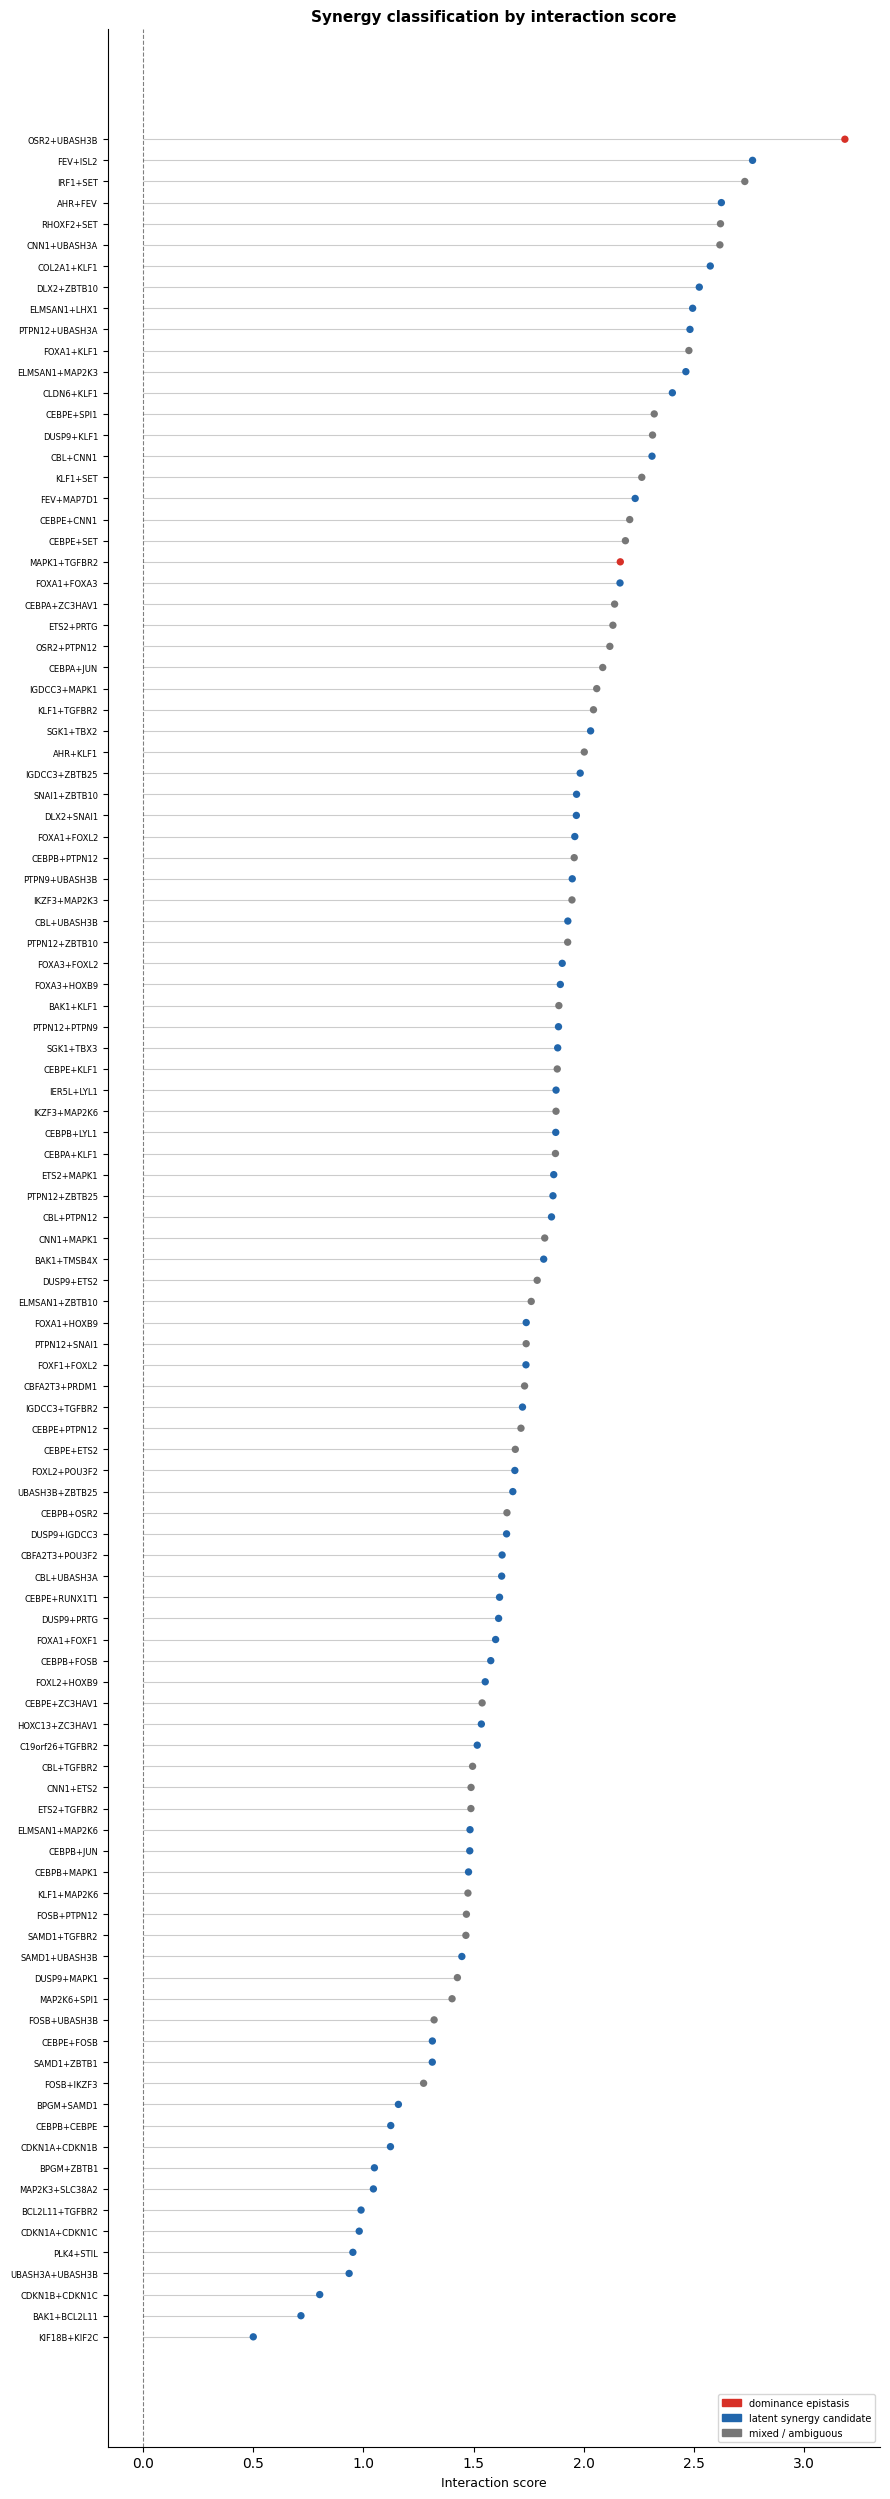

  ATE (all perts)    : 0.7149
  ATE (single perts) : 0.5951
  ATE (train combos) : 0.7671
  ATE (held-out)     : 0.7251  [n=26]
  Synergy Candidates : 61 / 105 classified

Run 3/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/800 [00:00<?, ?it/s…

⏹ Early stopping at epoch 637 (best ELBO=1384.2610)


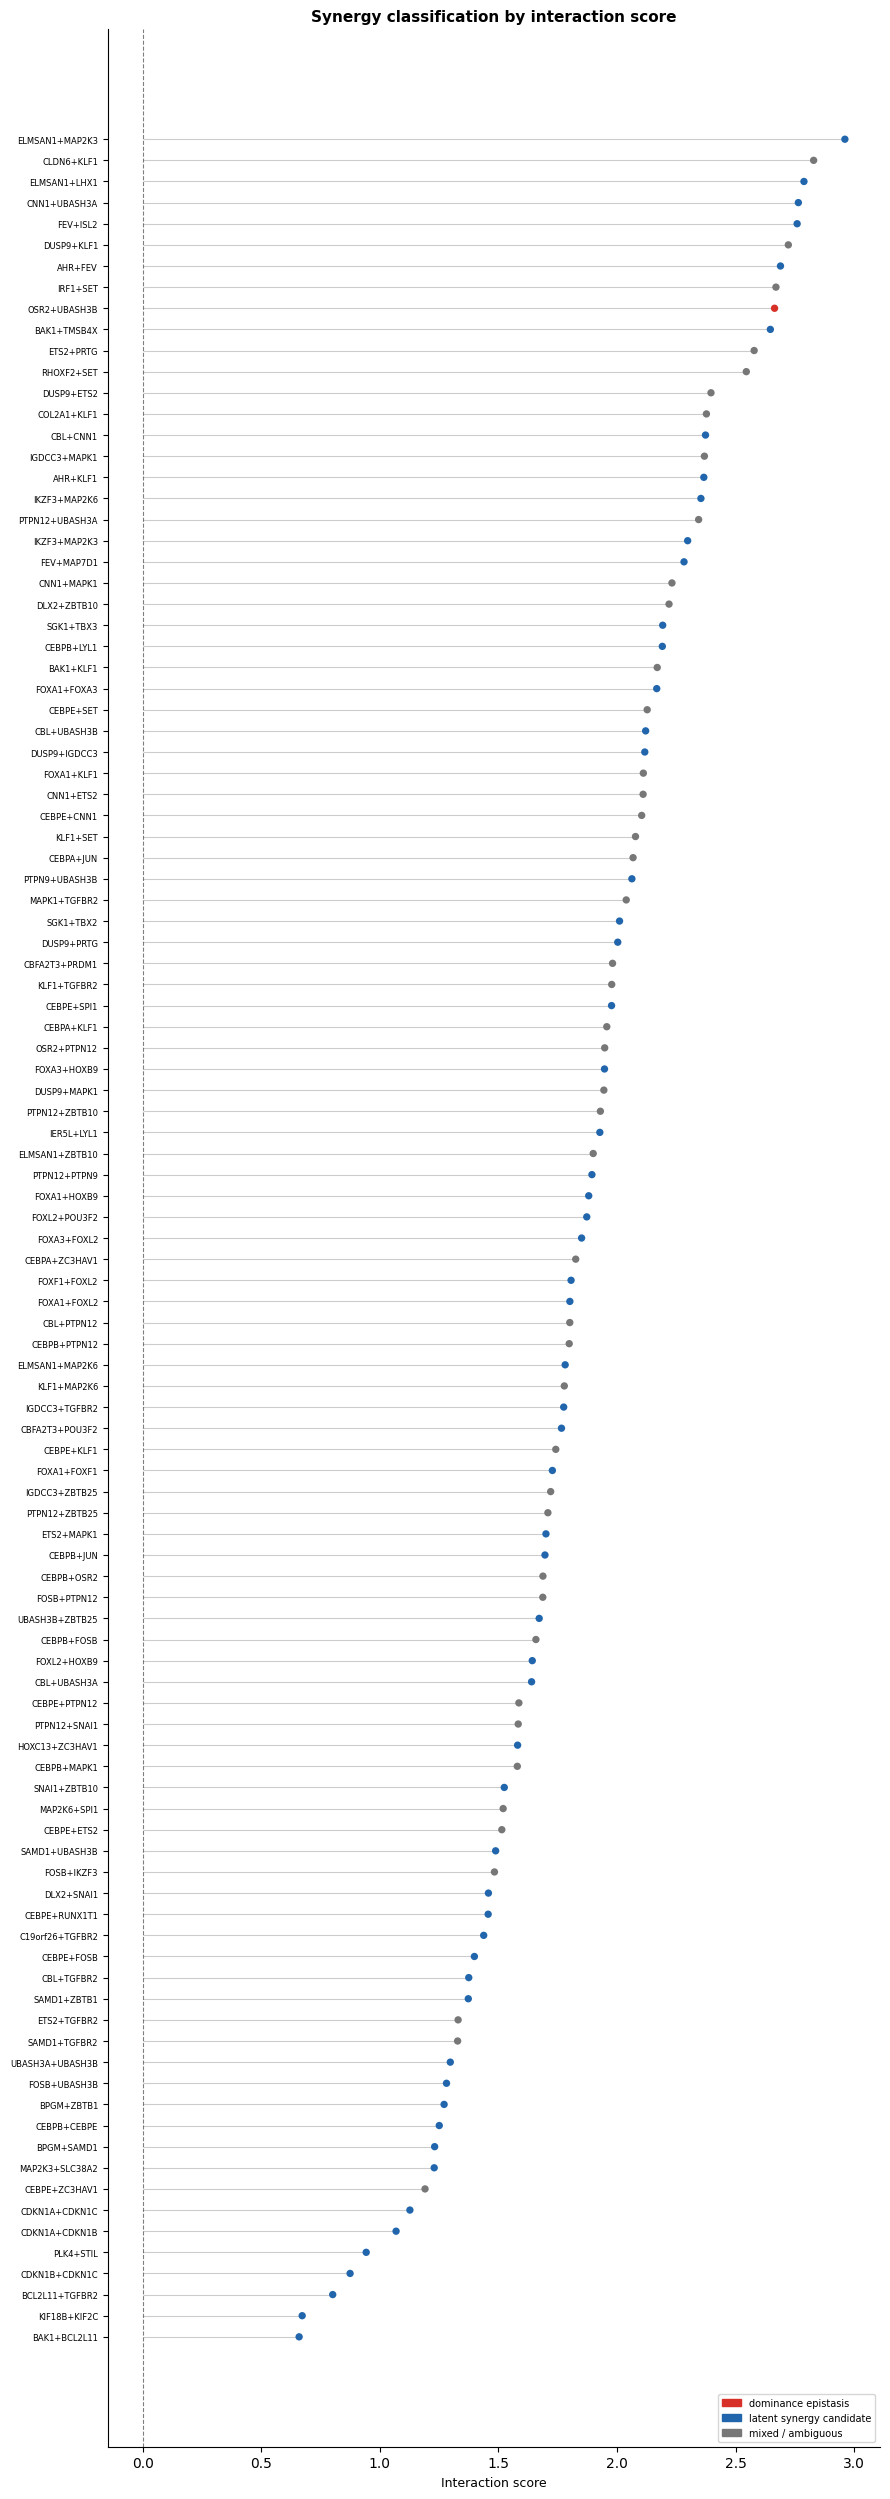

  ATE (all perts)    : 0.7142
  ATE (single perts) : 0.6282
  ATE (train combos) : 0.7563
  ATE (held-out)     : 0.7131  [n=26]
  Synergy Candidates : 59 / 105 classified

Run 4/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/800 [00:00<?, ?it/s…

⏹ Early stopping at epoch 519 (best ELBO=1387.5330)


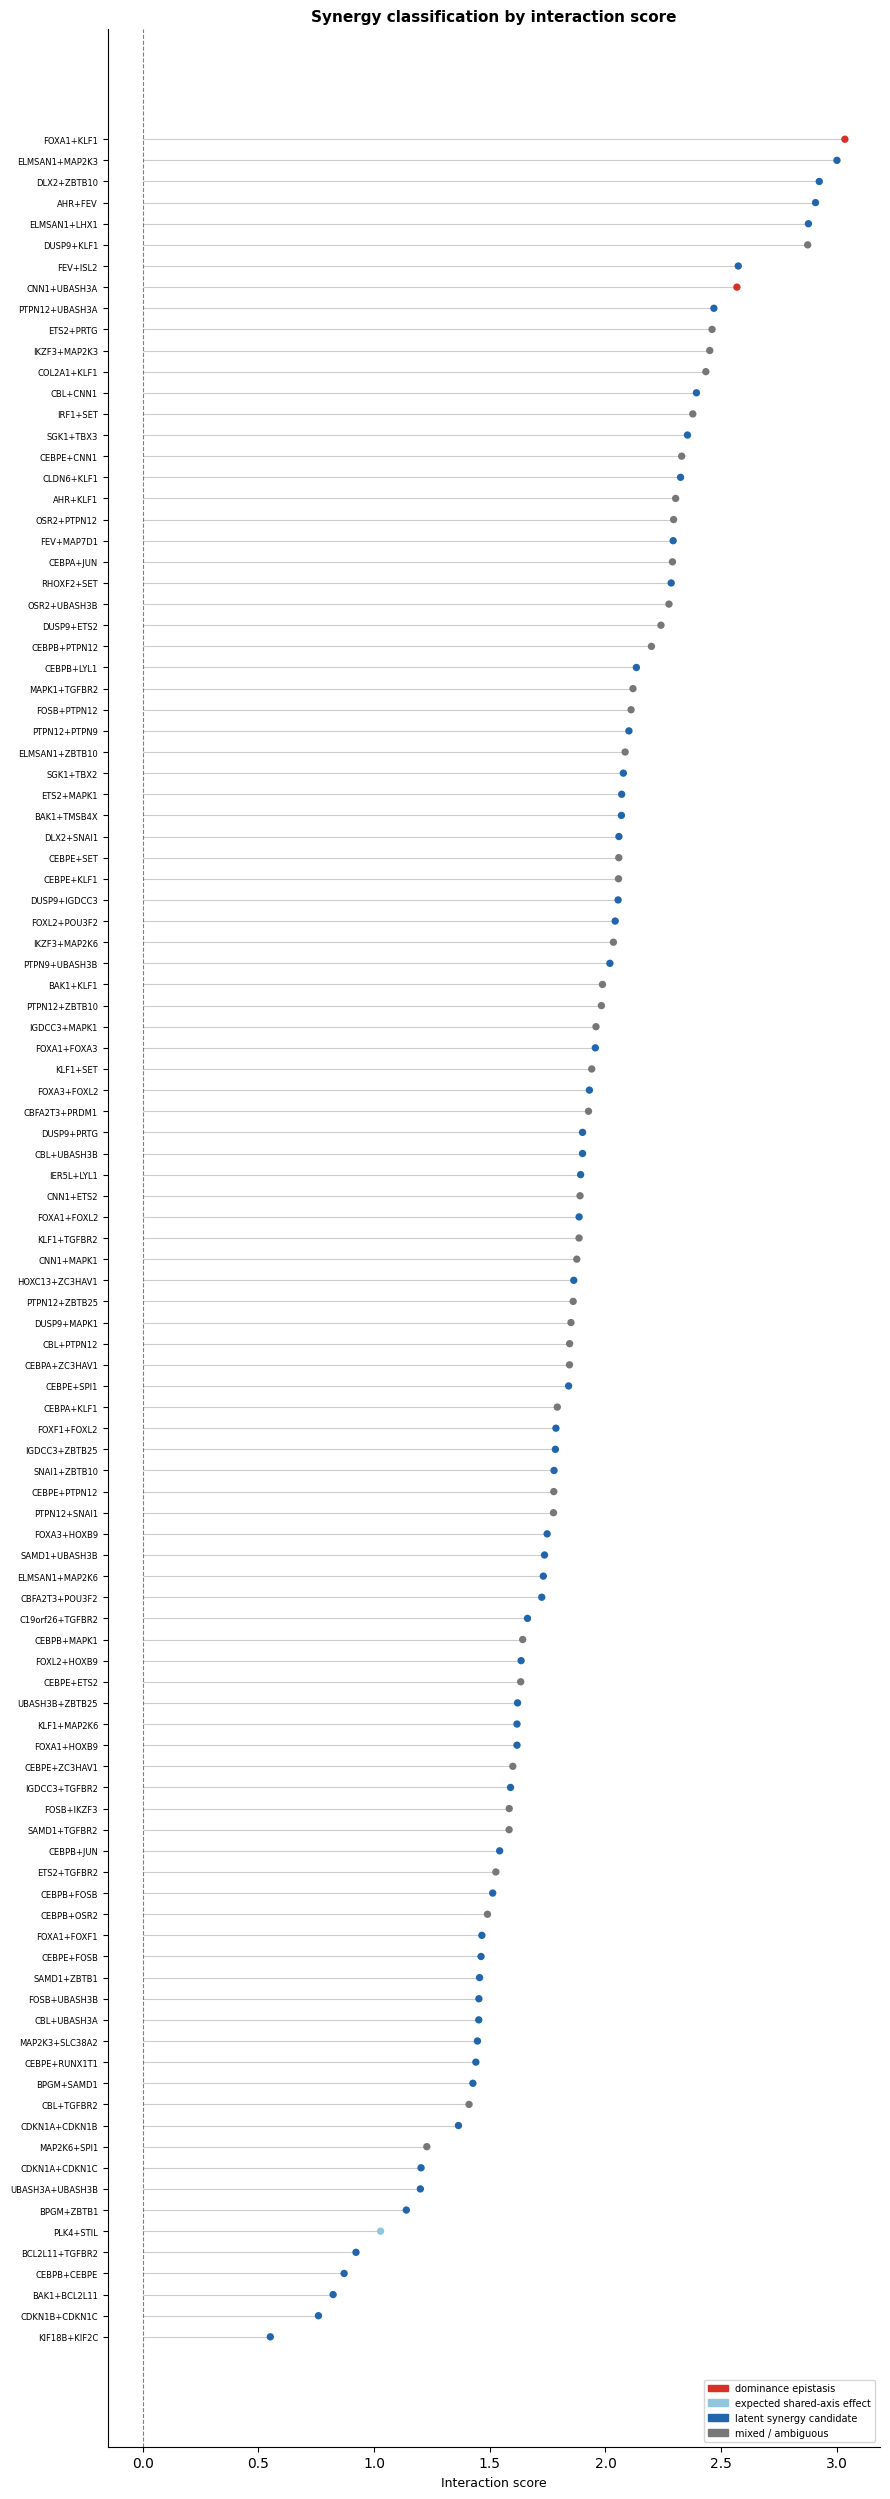

  ATE (all perts)    : 0.7097
  ATE (single perts) : 0.6285
  ATE (train combos) : 0.7449
  ATE (held-out)     : 0.7219  [n=26]
  Synergy Candidates : 60 / 105 classified

Run 5/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/800 [00:00<?, ?it/s…

⏹ Early stopping at epoch 710 (best ELBO=1383.3188)


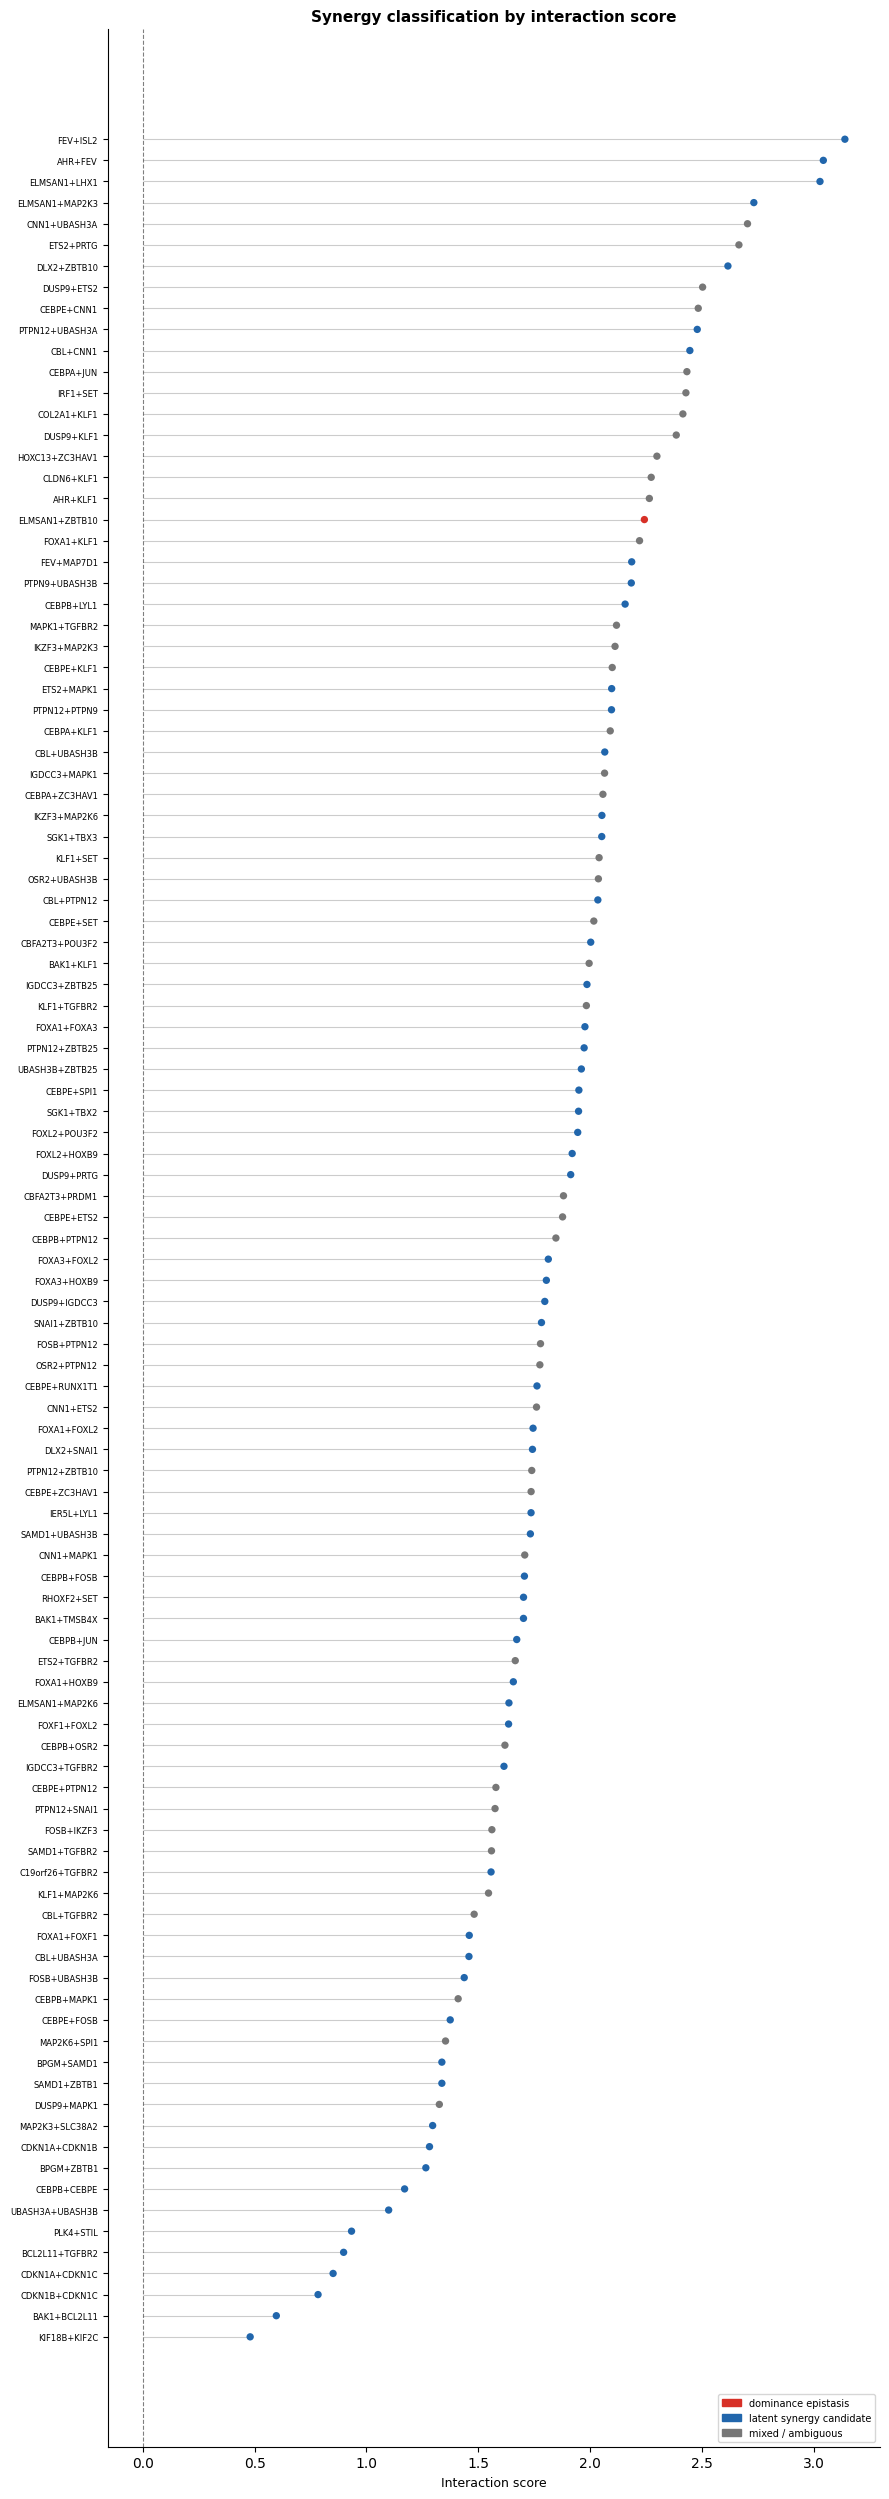

  ATE (all perts)    : 0.7249
  ATE (single perts) : 0.6286
  ATE (train combos) : 0.7678
  ATE (held-out)     : 0.7319  [n=26]
  Synergy Candidates : 61 / 105 classified

All runs complete successfully! Your data is fully captured.


In [12]:
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

run_results     = []
per_run_metrics = []

for run in range(N_RUNS):
    print(f"\n{'='*55}\nRun {run+1}/{N_RUNS}\n{'='*55}")

    # ---- Train Model ----
    results = slk.tl.run_single(
        train_data,
        model='vae',
        num_epochs=NUM_EPOCHS,
        validate_every=VALIDATE_EVERY,
        patience=PATIENCE,
        device=DEVICE,
        seed=run,
        combinatorial=True,
        use_synergy=True,
        **SHERLOCK_KWARGS,
    )
    model = results['model']

    # ---- Synergy detection on training combos ----
    slk.tl.eval_single(model, train_data, obsm_key='z', uns_key='results', device=DEVICE)
    
    # Isolate plot drawing engine safely
    plt.ioff()
    slk.pl.plot_synergy(train_data)
    plt.close('all') 
    
    # Extract the exact 'synergy' dataframe we inspected
    syn_df = train_data.uns['results']['synergy'].copy()
    
    # MATCH THE API: Sort by interaction_score descending (strongest interactions first)
    syn_df = syn_df.sort_values('interaction_score', ascending=False).reset_index(drop=True)
    
    # Filter candidates based on classification or score threshold. 
    # (Since there is no qval, we look for rows flagged as explicit synergy candidates)
    sig_syn = syn_df[syn_df['classification'].str.contains('synergy', na=False, case=False)].copy()

    # Canonical (sorted-tuple) pair representation for set operations using pert_a and pert_b
    sig_syn_set = set(
        tuple(sorted([row['pert_a'], row['pert_b']]))
        for _, row in sig_syn.iterrows()
    )
    effect_sizes = {
        tuple(sorted([row['pert_a'], row['pert_b']])): row['interaction_score']
        for _, row in syn_df.iterrows()
    }

    # ---- ATE on held-out combos ----
    try:
        ate = model.predict_counterfactual_effects(
            data,
            n_centroids=25,
            observed_effect=data.uns['treat_effect'],
        )
    except Exception as e:
        print(f'  Warning: ATE on full data failed ({e}), falling back to train_data')
        ate = model.predict_counterfactual_effects(
            train_data,
            n_centroids=25,
            observed_effect=data.uns['treat_effect'],
        )

    pred_df   = ate['predicted_df']
    obs_df    = ate['observed_df']
    ate_all_r = ate['corr']

    # ATE breakdown execution
    def _r(idx):
        idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
        if len(idx) < 2:
            return float('nan'), []
        x = pred_df.loc[idx].values.ravel()
        y = obs_df.loc[idx].values.ravel()
        v = np.isfinite(x) & np.isfinite(y)
        return (pearsonr(x[v], y[v])[0] if v.sum() > 2 else float('nan')), idx

    ate_single_r, _  = _r(single_perts)
    ate_train_r,  _  = _r(list(train_combos))
    ate_held_r, held_idx_found = _r(list(holdout_combos))

    held_pred = pred_df.loc[held_idx_found].copy() if held_idx_found else None

    # ---- Store Memory Results ----
    run_results.append({
        'run':          run,
        'model':        model,
        'syn_df':       syn_df,
        'sig_syn_set':  sig_syn_set,
        'n_sig':        len(sig_syn),
        'effect_sizes': effect_sizes,
        'ate_all_r':    ate_all_r,
        'ate_single_r': ate_single_r,
        'ate_train_r':  ate_train_r,
        'ate_held_r':   ate_held_r,
        'held_pred':    held_pred, 
    })

    per_run_metrics.append({
        'run':          run + 1,
        'ate_all_r':    ate_all_r,
        'ate_single_r': ate_single_r,
        'ate_train_r':  ate_train_r,
        'ate_held_r':   ate_held_r,
        'n_sig_syn':    len(sig_syn),
        'n_tested_syn': len(syn_df),
    })

    print(f'  ATE (all perts)    : {ate_all_r:.4f}')
    print(f'  ATE (single perts) : {ate_single_r:.4f}')
    print(f'  ATE (train combos) : {ate_train_r:.4f}')
    print(f'  ATE (held-out)     : {ate_held_r:.4f}  [n={len(held_idx_found)}]')
    print(f'  Synergy Candidates : {len(sig_syn)} / {len(syn_df)} classified')

    # Deep memory teardown
    if 'results' in locals(): del results
    torch.cuda.empty_cache()
    gc.collect()

print('\nAll runs complete successfully! Your data is fully captured.')

In [9]:
# --- QUICK INSPECTION TEST ---
# Run this right after eval_single on any dummy data or your first trial run:

print("Type of results:", type(train_data.uns.get('results')))

if isinstance(train_data.uns.get('results'), dict):
    print("Available keys in results dictionary:")
    for key, value in train_data.uns['results'].items():
        print(f"  - '{key}' (Type: {type(value)})")
elif isinstance(train_data.uns.get('results'), pd.DataFrame):
    print("The entire 'results' object is a DataFrame!")
    print("Columns:", train_data.uns['results'].columns)

Type of results: <class 'dict'>
Available keys in results dictionary:
  - 'z_corr' (Type: <class 'numpy.ndarray'>)
  - 'z_perts' (Type: <class 'numpy.ndarray'>)
  - 'z_embed' (Type: <class 'numpy.ndarray'>)
  - 'rho_corr' (Type: <class 'numpy.ndarray'>)
  - 'rho_perts' (Type: <class 'numpy.ndarray'>)
  - 'rho_embed' (Type: <class 'numpy.ndarray'>)
  - 'acc' (Type: <class 'float'>)
  - 'z_rho_corr' (Type: <class 'dict'>)
  - 'W' (Type: <class 'numpy.ndarray'>)
  - 'counterfactual_effect_size' (Type: <class 'numpy.ndarray'>)
  - 'condition_perturbation_interaction' (Type: <class 'numpy.ndarray'>)
  - 'conditions' (Type: <class 'numpy.ndarray'>)
  - 'synergy' (Type: <class 'pandas.core.frame.DataFrame'>)


In [13]:
# --- QUICK COLUMN INSPECTION ---
syn_df = train_data.uns['results']['synergy']
print("Exact columns in the synergy DataFrame:")
print(list(syn_df.columns))

print("\nFirst 2 rows for reference:")
print(syn_df.head(2))

Exact columns in the synergy DataFrame:
['pert_a', 'pert_b', 'dominant_pert', 'n_a', 'n_b', 'n_ab', 'cos_a_b', 'cos_ab_a', 'cos_ab_b', 'cos_ab_shared', 'proj_residual', 'dom_residual', 'interaction_score', 'classification']

First 2 rows for reference:
         pert_a pert_b dominant_pert  n_a   n_b  n_ab   cos_a_b  cos_ab_a  \
AHR+FEV     AHR    FEV          None  558   703   276  0.670883  0.923138   
AHR+KLF1    AHR   KLF1          None  558  1954   481  0.424175  0.830228   

          cos_ab_b  cos_ab_shared  proj_residual  dom_residual  \
AHR+FEV   0.888637       0.991097       2.849605      2.816229   
AHR+KLF1  0.835715       0.987105       2.061963      1.748576   

          interaction_score            classification  
AHR+FEV            3.043468  latent synergy candidate  
AHR+KLF1           2.265377         mixed / ambiguous  


## Per-run metrics

In [14]:
metrics_df = pd.DataFrame(per_run_metrics).set_index('run')
print(metrics_df.round(4).to_string())
print('\nMean ± Std:')
for col in metrics_df.columns:
    v = pd.to_numeric(metrics_df[col], errors='coerce').dropna().values
    if len(v):
        print(f'  {col:22s}: {np.mean(v):.4f} ± {np.std(v):.4f}')
    else:
        print(f'  {col:22s}: N/A')

     ate_all_r  ate_single_r  ate_train_r  ate_held_r  n_sig_syn  n_tested_syn
run                                                                           
1       0.6917        0.5565       0.7432      0.7214         57           105
2       0.7149        0.5951       0.7671      0.7251         61           105
3       0.7142        0.6282       0.7563      0.7131         59           105
4       0.7097        0.6285       0.7449      0.7219         60           105
5       0.7249        0.6286       0.7678      0.7319         61           105

Mean ± Std:
  ate_all_r             : 0.7111 ± 0.0109
  ate_single_r          : 0.6074 ± 0.0285
  ate_train_r           : 0.7559 ± 0.0105
  ate_held_r            : 0.7227 ± 0.0061
  n_sig_syn             : 59.6000 ± 1.4967
  n_tested_syn          : 105.0000 ± 0.0000


## Significant synergy overlap across runs

For each pair of runs, compute:
1. **Jaccard similarity** of the sets of significant synergy pairs (q < threshold).
2. **Pearson r of effect sizes** over all tested pairs shared between runs.

In [15]:
pairs = list(combinations(range(N_RUNS), 2))

jaccard_syn  = []
effect_corrs = []
ate_pred_corrs = []

for i, j in pairs:
    ri, rj = run_results[i], run_results[j]

    # --- Jaccard over significant synergy pairs ---
    si    = ri['sig_syn_set']
    sj    = rj['sig_syn_set']
    union = si | sj
    inter = si & sj
    jaccard_syn.append(len(inter) / len(union) if union else float('nan'))

    # --- Effect size Pearson r (shared tested pairs) ---
    ei     = ri['effect_sizes']
    ej     = rj['effect_sizes']
    shared = sorted(set(ei) & set(ej))
    if len(shared) > 2:
        vi = np.array([ei[p] for p in shared])
        vj = np.array([ej[p] for p in shared])
        r, _ = pearsonr(vi, vj)
        effect_corrs.append(r)
    else:
        effect_corrs.append(float('nan'))

    # --- Pairwise ATE prediction correlation (held-out combos) ---
    pi = ri['held_pred']
    pj = rj['held_pred']
    if pi is not None and pj is not None:
        common = pi.index.intersection(pj.index)
        if len(common) > 1:
            xi = pi.loc[common].values.ravel()
            xj = pj.loc[common].values.ravel()
            v  = np.isfinite(xi) & np.isfinite(xj)
            ate_pred_corrs.append(pearsonr(xi[v], xj[v])[0] if v.sum() > 2 else float('nan'))
        else:
            ate_pred_corrs.append(float('nan'))
    else:
        ate_pred_corrs.append(float('nan'))

pair_labels = [f'run{i+1}–run{j+1}' for i, j in pairs]

syn_summary = pd.DataFrame({
    'pair':              pair_labels,
    'jaccard_sig_syn':   jaccard_syn,
    'effect_size_corr':  effect_corrs,
    'ate_pred_corr':     ate_pred_corrs,
})
print(syn_summary.to_string(index=False))
print('\nMean ± Std:')
for col in ['jaccard_sig_syn', 'effect_size_corr', 'ate_pred_corr']:
    v = syn_summary[col].dropna().values
    if len(v):
        print(f'  {col:22s}: {np.mean(v):.4f} ± {np.std(v):.4f}')

     pair  jaccard_sig_syn  effect_size_corr  ate_pred_corr
run1–run2         0.873016          0.852199       0.940256
run1–run3         0.757576          0.887687       0.937261
run1–run4         0.800000          0.898661       0.954181
run1–run5         0.873016          0.901564       0.956356
run2–run3         0.764706          0.870217       0.940936
run2–run4         0.861538          0.870565       0.950807
run2–run5         0.876923          0.850373       0.946489
run3–run4         0.803030          0.878067       0.943308
run3–run5         0.818182          0.844349       0.945034
run4–run5         0.890625          0.895374       0.953876

Mean ± Std:
  jaccard_sig_syn       : 0.8319 ± 0.0467
  effect_size_corr      : 0.8749 ± 0.0199
  ate_pred_corr         : 0.9469 ± 0.0063


## Core synergies (present in all / most runs)

A synergy that appears significant in every run is a robust finding; one that appears in only one run may be noise.

In [16]:
all_sig_sets = [r['sig_syn_set'] for r in run_results]
core_syns    = set.intersection(*all_sig_sets) if all_sig_sets else set()
any_syns     = set.union(*all_sig_sets)         if all_sig_sets else set()

freq_syn = {pair: sum(pair in s for s in all_sig_sets) for pair in any_syns}
freq_df  = pd.DataFrame(
    [{'pair': f'{a}+{b}', 'n_runs': n, 'a': a, 'b': b} for (a, b), n in freq_syn.items()]
).sort_values(['n_runs', 'pair'], ascending=[False, True]).reset_index(drop=True)

print(f'Synergies significant in ALL {N_RUNS} runs : {len(core_syns)}')
print(f'Synergies significant in ≥{N_RUNS-1} runs  : {(freq_df["n_runs"] >= N_RUNS-1).sum()}')
print(f'Synergies significant in ANY run           : {len(any_syns)}')
print()
print(freq_df[['pair', 'n_runs']].to_string(index=False))

Synergies significant in ALL 5 runs : 48
Synergies significant in ≥4 runs  : 55
Synergies significant in ANY run           : 71

           pair  n_runs
        AHR+FEV       5
   BAK1+BCL2L11       5
    BAK1+TMSB4X       5
 BCL2L11+TGFBR2       5
     BPGM+SAMD1       5
     BPGM+ZBTB1       5
C19orf26+TGFBR2       5
 CBFA2T3+POU3F2       5
       CBL+CNN1       5
    CBL+UBASH3A       5
    CBL+UBASH3B       5
  CDKN1A+CDKN1B       5
  CDKN1A+CDKN1C       5
  CDKN1B+CDKN1C       5
    CEBPB+CEBPE       5
     CEBPB+LYL1       5
     CEBPE+FOSB       5
  CEBPE+RUNX1T1       5
     DLX2+SNAI1       5
   DUSP9+IGDCC3       5
     DUSP9+PRTG       5
   ELMSAN1+LHX1       5
 ELMSAN1+MAP2K3       5
 ELMSAN1+MAP2K6       5
     ETS2+MAPK1       5
       FEV+ISL2       5
     FEV+MAP7D1       5
    FOXA1+FOXA3       5
    FOXA1+FOXF1       5
    FOXA1+FOXL2       5
    FOXA1+HOXB9       5
    FOXA3+FOXL2       5
    FOXA3+HOXB9       5
    FOXF1+FOXL2       5
    FOXL2+HOXB9       5
   FOXL

## Synergy effect sizes for core pairs

For the pairs significant in all runs, show effect size per run to assess magnitude consistency.

In [17]:
if core_syns:
    rows = []
    for pair in sorted(core_syns):
        row = {'pair': f'{pair[0]}+{pair[1]}'}
        for r in run_results:
            row[f'run{r["run"]+1}_eff'] = r['effect_sizes'].get(pair, float('nan'))
        rows.append(row)
    core_df = pd.DataFrame(rows).set_index('pair')
    print('Effect sizes for core synergies (significant in all runs):')
    print(core_df.round(4).to_string())

    # per-pair CV
    eff_cols = [c for c in core_df.columns if c.endswith('_eff')]
    core_df['mean_eff'] = core_df[eff_cols].mean(axis=1)
    core_df['std_eff']  = core_df[eff_cols].std(axis=1)
    core_df['cv']       = core_df['std_eff'] / core_df['mean_eff'].abs()
    print('\nCoefficient of variation (effect size):')
    print(core_df[['mean_eff', 'std_eff', 'cv']].round(4).to_string())
else:
    print('No synergies were significant in all runs.')

Effect sizes for core synergies (significant in all runs):
                 run1_eff  run2_eff  run3_eff  run4_eff  run5_eff
pair                                                             
AHR+FEV            2.7321    2.6241    2.6894    2.9080    3.0435
BAK1+BCL2L11       0.4202    0.7173    0.6593    0.8225    0.5970
BAK1+TMSB4X        2.1826    1.8182    2.6467    2.0689    1.7025
BCL2L11+TGFBR2     0.6855    0.9898    0.8009    0.9215    0.8980
BPGM+SAMD1         1.3356    1.1592    1.2308    1.4269    1.3375
BPGM+ZBTB1         1.2477    1.0504    1.2707    1.1391    1.2658
C19orf26+TGFBR2    1.5043    1.5168    1.4377    1.6628    1.5574
CBFA2T3+POU3F2     1.8132    1.6295    1.7658    1.7245    2.0032
CBL+CNN1           2.4976    2.3095    2.3732    2.3932    2.4466
CBL+UBASH3A        1.6197    1.6276    1.6397    1.4522    1.4586
CBL+UBASH3B        1.8985    1.9277    2.1207    1.9007    2.0660
CDKN1A+CDKN1B      1.5108    1.1232    1.0682    1.3645    1.2821
CDKN1A+CDKN1C    

## Visualisation — reproducibility metrics

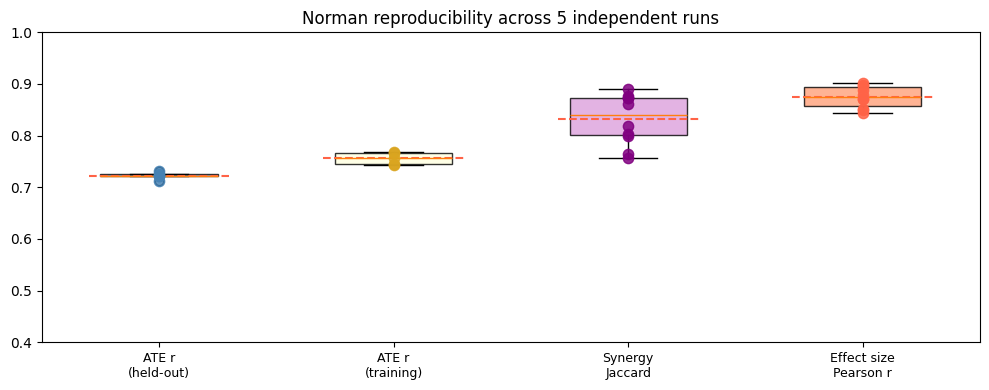

In [18]:
metric_info = [
    ([r['ate_held_r']  for r in run_results], 'ATE r\n(held-out)',      'lightsteelblue', 'steelblue'),
    ([r['ate_train_r'] for r in run_results], 'ATE r\n(training)',      'lightyellow',    'goldenrod'),
    # ([r['n_sig']       for r in run_results], f'# Sig syn\n(q<{SYN_Q_THRESH})', 'lightgreen', 'seagreen'),
    (jaccard_syn,                             'Synergy\nJaccard',       'plum',           'purple'),
    (effect_corrs,                            'Effect size\nPearson r', 'lightsalmon',    'tomato'),
]

fig, ax = plt.subplots(figsize=(10, 4))

for pos, (values, title, fc, sc) in enumerate(metric_info, 1):
    clean = [v for v in values if np.isfinite(v)]
    if not clean:
        continue
    ax.boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=fc, alpha=0.8))
    ax.scatter([pos]*len(clean), clean, color=sc, s=55, zorder=3, alpha=0.85)
    m = np.mean(clean)
    ax.plot([pos - 0.3, pos + 0.3], [m, m], color='tomato', linestyle='--', lw=1.5,
            label=f'mean={m:.3f}')

ax.set_xticks(range(1, len(metric_info) + 1))
ax.set_xticklabels([m[1] for m in metric_info], fontsize=9)
ax.set_title(f'Norman reproducibility across {N_RUNS} independent runs', fontsize=12)
ax.set_ylim(bottom=0.4, top=1)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_boxplots.png', bbox_inches='tight')
plt.show()


## Pairwise heatmaps

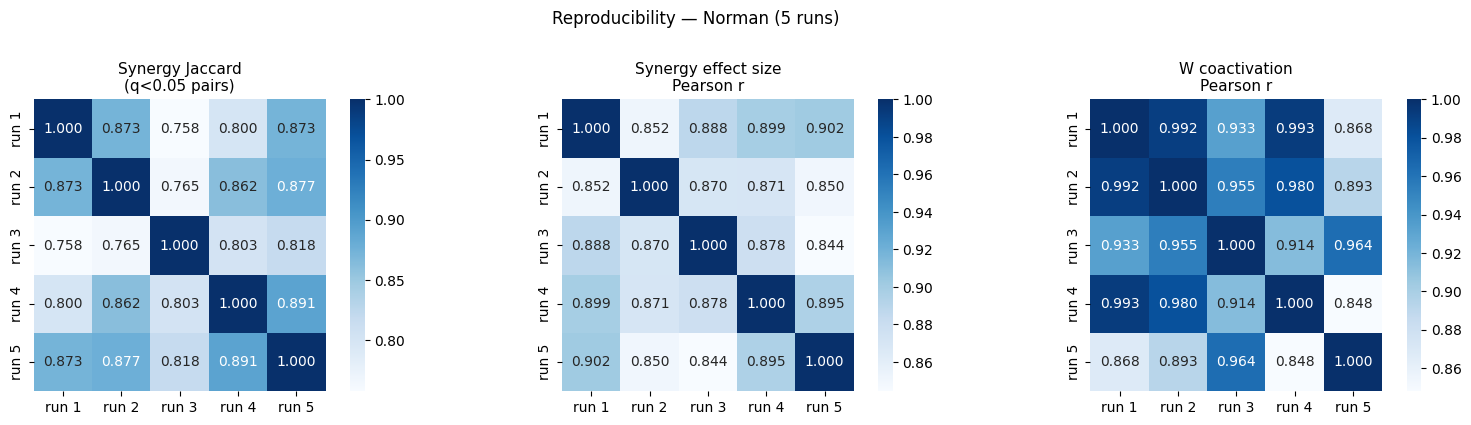

In [19]:
def to_matrix(values, n_runs, pairs, diag=1.0):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, diag)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

# W coactivation: compare W @ W.T across runs (permutation-invariant)
# C[a,b] = dot product of perturbation a and b's gate vectors = how much they share active dims
W_list  = [r['model'].gate(deterministic=True).detach().cpu().numpy() for r in run_results]
C_list  = [W @ W.T for W in W_list]   # (P, P) coactivation matrices

def triu_vals(M):
    idx = np.triu_indices(M.shape[0], k=1)
    return M[idx]

w_corrs = []
for i, j in pairs:
    ci = triu_vals(C_list[i])
    cj = triu_vals(C_list[j])
    r, _ = pearsonr(ci, cj)
    w_corrs.append(r)

J_mat = to_matrix(jaccard_syn, N_RUNS, pairs)
E_mat = to_matrix(effect_corrs, N_RUNS, pairs)
W_mat = to_matrix(w_corrs, N_RUNS, pairs)

run_labels = [f'run {k+1}' for k in range(N_RUNS)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (mat, title) in zip(axes, [
    (J_mat, 'Synergy Jaccard\n(q<0.05 pairs)'),
    (E_mat, 'Synergy effect size\nPearson r'),
    (W_mat, 'W coactivation\nPearson r'),
]):
    off_diag = mat[~np.eye(N_RUNS, dtype=bool)]
    vmin = np.nanmin(off_diag)
    sns.heatmap(mat, ax=ax, annot=True, fmt='.3f',
                vmin=vmin, vmax=1.0, cmap='Blues',
                xticklabels=run_labels, yticklabels=run_labels, square=True)
    ax.set_title(title, fontsize=11)

plt.suptitle(f'Reproducibility — Norman ({N_RUNS} runs)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_heatmaps.png', bbox_inches='tight')
plt.show()


## Synergy frequency bar chart

Shows how many runs each synergy pair was significant in.  
Dark blue = significant in all runs (core); light blue = majority; grey = minority.

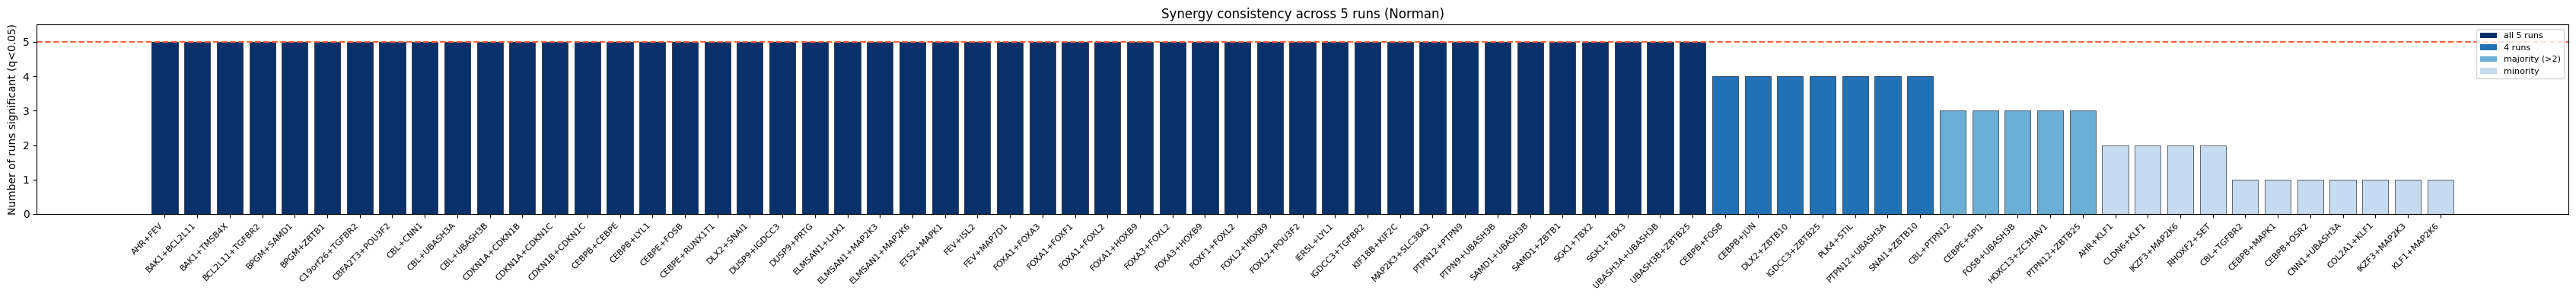

In [20]:
if len(freq_df) == 0:
    print('No synergies found.')
else:
    colors = [
        '#08306b' if n == N_RUNS
        else '#2171b5' if n >= N_RUNS - 1
        else '#6baed6' if n >= N_RUNS // 2 + 1
        else '#c6dbef'
        for n in freq_df['n_runs']
    ]

    fig, ax = plt.subplots(figsize=(max(8, len(freq_df) * 0.45 + 2), 4))
    ax.bar(range(len(freq_df)), freq_df['n_runs'], color=colors,
           edgecolor='k', linewidth=0.4)
    ax.set_xticks(range(len(freq_df)))
    ax.set_xticklabels(freq_df['pair'], rotation=45, ha='right', fontsize=8)
    ax.axhline(N_RUNS, color='tomato', linestyle='--', lw=1.5, label=f'all {N_RUNS} runs')
    ax.set_ylabel(f'Number of runs significant (q<{SYN_Q_THRESH})')
    ax.set_ylim(0, N_RUNS + 0.5)
    ax.set_title(f'Synergy consistency across {N_RUNS} runs (Norman)')
    ax.legend(fontsize=9)

    from matplotlib.patches import Patch
    legend_patches = [
        Patch(fc='#08306b', label=f'all {N_RUNS} runs'),
        Patch(fc='#2171b5', label=f'{N_RUNS-1} runs'),
        Patch(fc='#6baed6', label=f'majority (>{N_RUNS//2})'),
        Patch(fc='#c6dbef', label='minority'),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/figures/synergy_frequency.png', bbox_inches='tight')
    plt.show()

## ATE scatter: held-out combos

Predicted vs observed ATE for the held-out combo perturbations for each run.

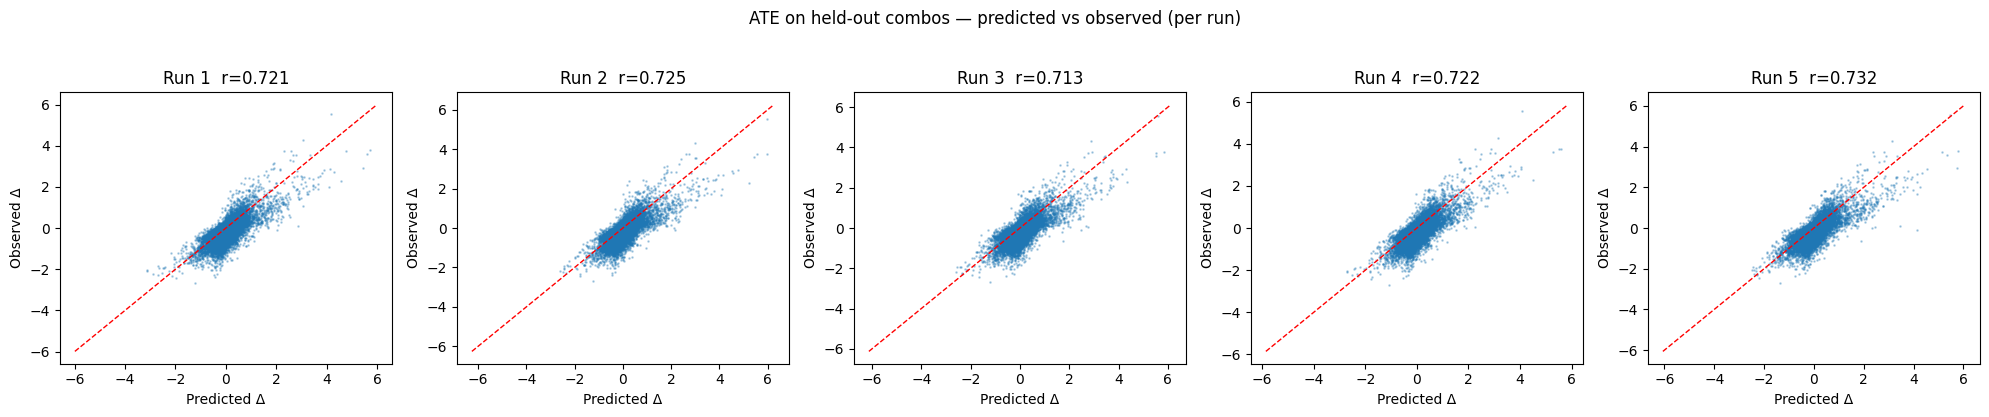

In [21]:
fig, axes = plt.subplots(1, N_RUNS, figsize=(4 * N_RUNS, 4), sharex=False, sharey=False)

obs_df_full = data.uns['treat_effect'].to_df()

for ax, r in zip(axes, run_results):
    hp = r['held_pred']
    if hp is None:
        ax.set_title(f"Run {r['run']+1}\nN/A")
        continue

    common = hp.index.intersection(obs_df_full.index)
    if len(common) == 0:
        ax.set_title(f"Run {r['run']+1}\nN/A")
        continue

    x_flat = hp.loc[common].values.ravel()
    y_flat = obs_df_full.loc[common].values.ravel()
    v      = np.isfinite(x_flat) & np.isfinite(y_flat)

    ax.scatter(x_flat[v], y_flat[v], s=0.8, alpha=0.3, rasterized=True)
    lim = max(np.abs(x_flat[v]).max(), np.abs(y_flat[v]).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlabel('Predicted Δ')
    ax.set_ylabel('Observed Δ')
    ax.set_title(f"Run {r['run']+1}  r={r['ate_held_r']:.3f}")

fig.suptitle('ATE on held-out combos — predicted vs observed (per run)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/ate_holdout_scatter.png', bbox_inches='tight')
plt.show()